In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('C:\\Users\\nmims.student\\AirPassengers.csv')

In [5]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [6]:
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month')

In [7]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Passengers')

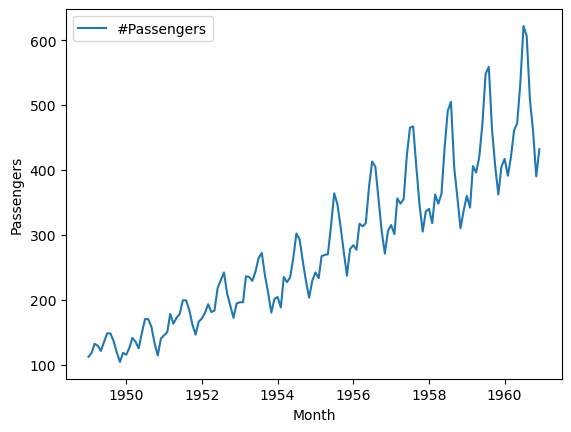

In [8]:
sns.lineplot(df)
plt.ylabel('Passengers')

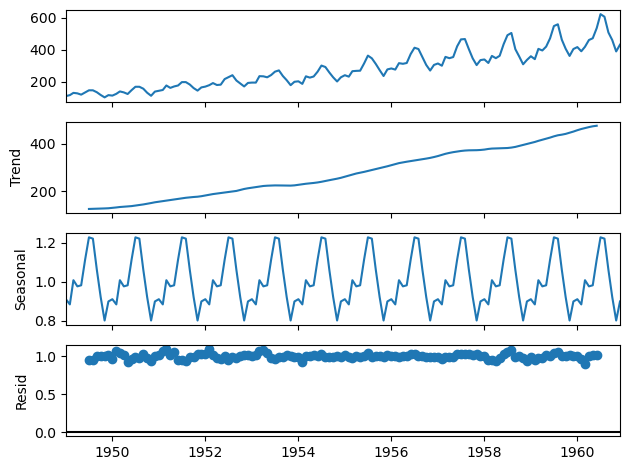

In [9]:
result = seasonal_decompose(df[['#Passengers']], model='multiplicative')
result.plot()
plt.show()

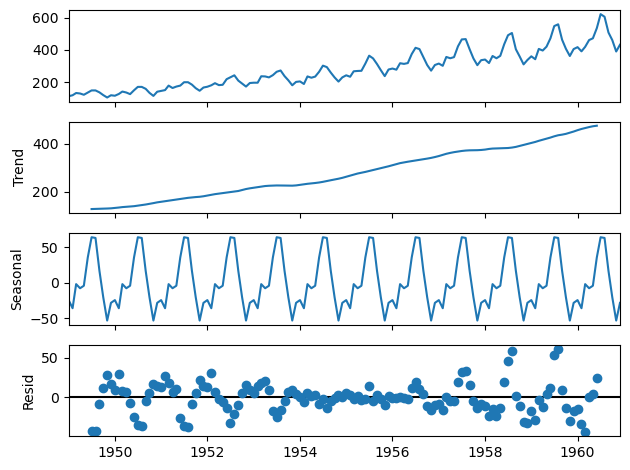

In [10]:
result = seasonal_decompose(df[['#Passengers']], model='additive')
result.plot()
plt.show()

In [11]:
pip install pymannkendall

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [12]:
import pymannkendall as mk

#perform Mann-Kendall test
#H0: There is no monotonic trend in the series

mk.original_test(df['#Passengers'])

Mann_Kendall_Test(trend='increasing', h=True, p=0.0, z=14.381610025544802, Tau=0.8087606837606838, s=8327.0, var_s=335164.3333333333, slope=2.451216287678477, intercept=90.23803543098887)

In [13]:
#p-value<0.5 reject H0 there is a trend present
train_df = df[:int(df.shape[0]*0.7)]
test_df = df[int(df.shape[0]*0.7):]

In [14]:
train_df.shape

(100, 1)

In [15]:
#Single Exponential Smoothing
from statsmodels.tsa.api import SimpleExpSmoothing
model = SimpleExpSmoothing(train_df)
model_single_fit = model.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [16]:
forecast_single = model_single_fit.forecast(6)
print(forecast_single)

1957-05-01    348.0
1957-06-01    348.0
1957-07-01    348.0
1957-08-01    348.0
1957-09-01    348.0
1957-10-01    348.0
Freq: MS, dtype: float64


In [17]:
forecast_single = model_single_fit.forecast(40)
model_single_fit.params

{'smoothing_level': 0.9999999850984761,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 112.0,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

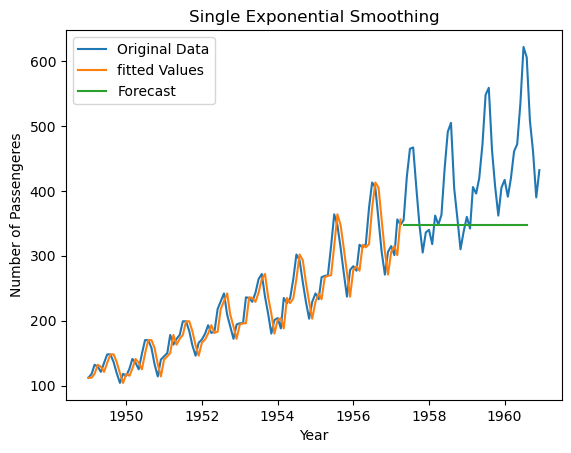

In [18]:
plt.plot(df,label='Original Data')
plt.plot(model_single_fit.fittedvalues, label='fitted Values')
plt.plot(forecast_single, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengeres')
plt.title('Single Exponential Smoothing')
plt.legend()
plt.show()

In [19]:
#Double Exponential Smoothing

from statsmodels.tsa.api import Holt

model_double = Holt(train_df)
model_double_fit = model_double.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [20]:
forecast_double = model_double_fit.forecast(6)
print(forecast_double)

1957-05-01    352.149928
1957-06-01    356.289994
1957-07-01    360.430061
1957-08-01    364.570127
1957-09-01    368.710193
1957-10-01    372.850259
Freq: MS, dtype: float64


In [21]:
forecast_double = model_double_fit.forecast(40)
model_double_fit.params

{'smoothing_level': 0.999190910127339,
 'smoothing_trend': 0.007412899330137531,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 112.0,
 'initial_trend': 6.0,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

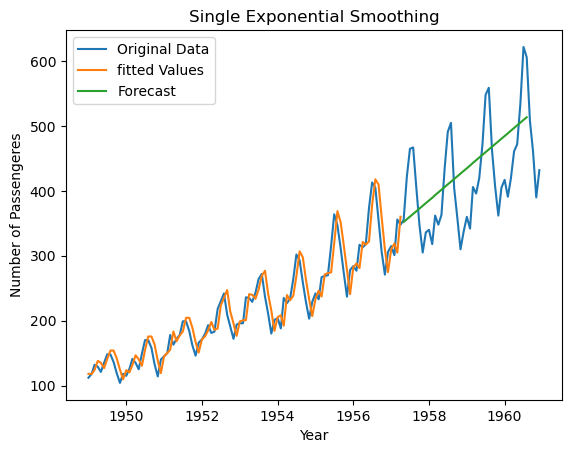

In [22]:
plt.plot(df,label='Original Data')
plt.plot(model_double_fit.fittedvalues, label='fitted Values')
plt.plot(forecast_double, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengeres')
plt.title('Single Exponential Smoothing')
plt.legend()
plt.show()

In [23]:
#Triple Exponential Smoothing

from statsmodels.tsa.api import ExponentialSmoothing

model_triple = ExponentialSmoothing(train_df, seasonal_periods = 12, trend='add', seasonal='add')
model_triple_fit = model_triple.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [24]:
forecast_triple = model_triple_fit.forecast(6)
print(forecast_triple)

1957-05-01    351.239556
1957-06-01    403.308146
1957-07-01    439.936813
1957-08-01    426.799787
1957-09-01    375.972869
1957-10-01    329.109279
Freq: MS, dtype: float64


In [25]:
forecast_triple = model_triple_fit.forecast(40)
model_triple_fit.params

{'smoothing_level': 0.2550250780260589,
 'smoothing_trend': 1.800645950512257e-09,
 'smoothing_seasonal': 0.7449749171421274,
 'damping_trend': nan,
 'initial_level': 118.7941010710188,
 'initial_trend': 2.3251129433904585,
 'initial_seasons': array([ -9.11783738,  -3.51563904,   8.9645761 ,   3.69243412,
         -5.06898002,   9.03423164,  21.25027253,  18.82286355,
          4.68963164, -14.11839322, -28.56031593, -11.9475752 ]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

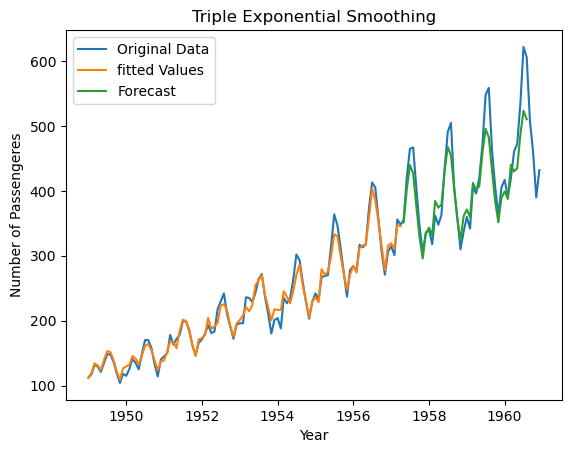

In [26]:
plt.plot(df,label='Original Data')
plt.plot(model_triple_fit.fittedvalues, label='fitted Values')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Year')
plt.ylabel('Number of Passengeres')
plt.title('Triple Exponential Smoothing')
plt.legend()
plt.show()

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
mape_train =  mean_absolute_percentage_error(train_df['#Passengers'], model_triple_fit.fittedvalues)
print('MAPE for train data:', mape_train)

MAPE for train data: 0.035383571364856876


In [28]:
#Practical-2 Checking Stationary
#ADF Test
#h0-series is not stationary vs h1-series is stationary

In [30]:
from statsmodels.tsa.stattools import adfuller
print('Results of the Dickey Fuller Test:')
dftest = adfuller(df['#Passengers'])
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#this is not stationary

Results of the Dickey Fuller Test:
Test Statistic              0.815369
P-value                     0.991880
#Lags used                 13.000000
Number of Observations    130.000000
Critical Value(1%)         -3.481682
Critical Value(5%)         -2.884042
Critical Value(10%)        -2.578770
dtype: float64


In [31]:
#KPSS Test
#h0-series is stationary vs h1-series is not stationary

In [33]:
from statsmodels.tsa.stattools import kpss
kp = kpss(df['#Passengers'])
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#this is not stationary

p-value for KPSS test (untransformed) =  0.01


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_2212\3758791204.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(df['#Passengers'])


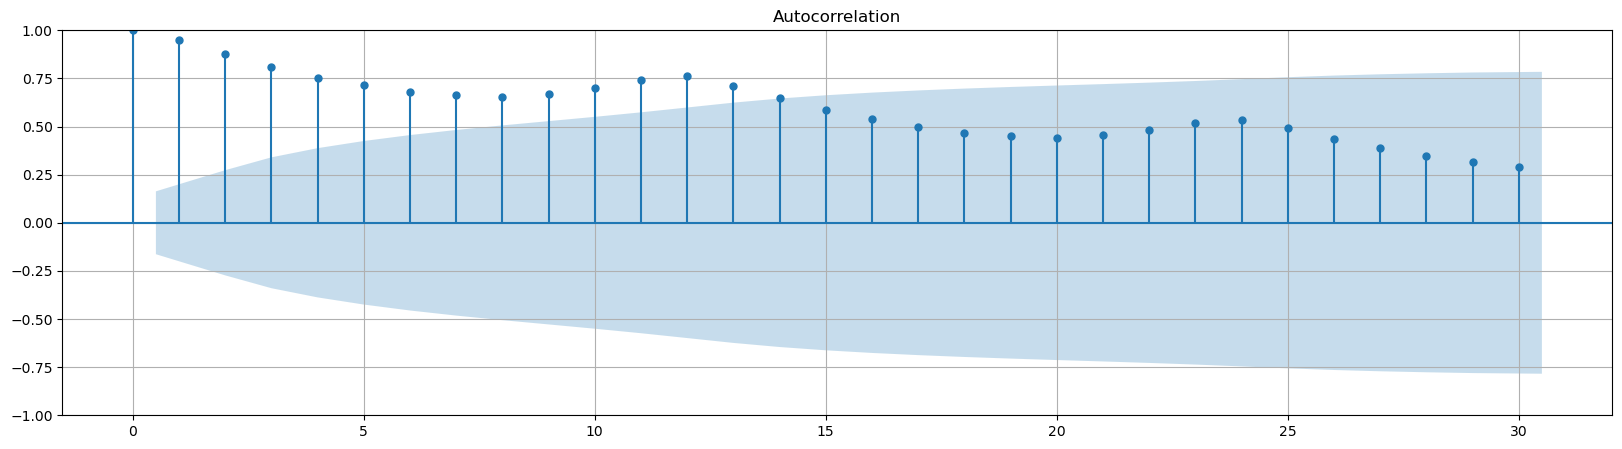

In [35]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(df['#Passengers'], ax=plt.gca(), lags=30)
plt.show()
#not stationary

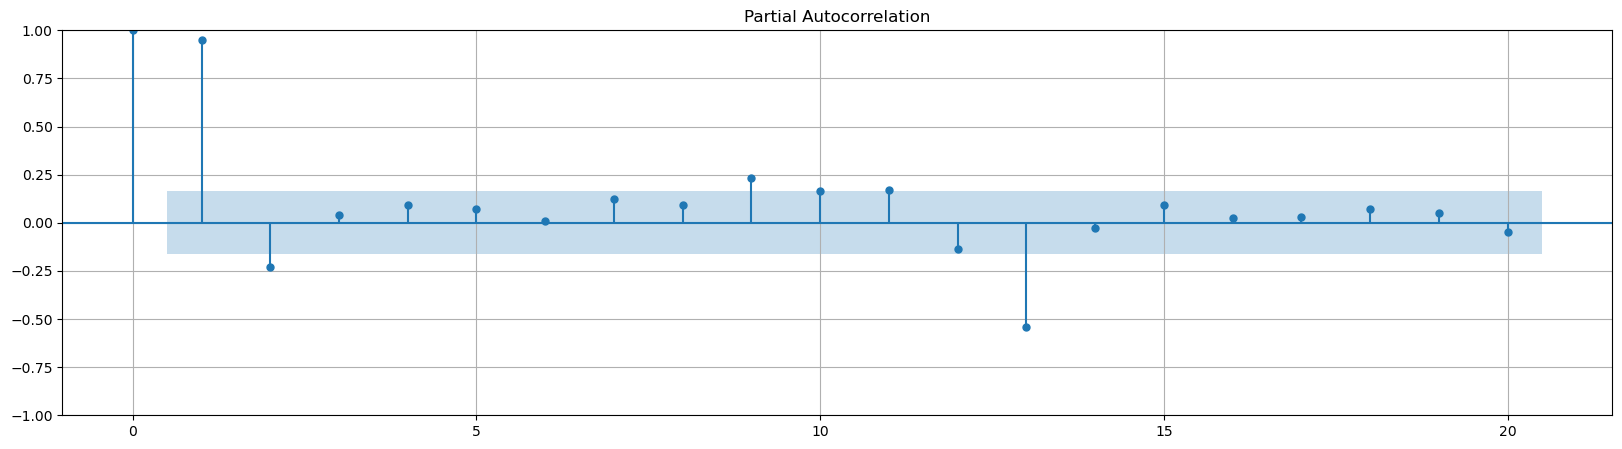

In [37]:
plt.figure(figsize=(20,5))
plt.grid()
plot_pacf(df['#Passengers'], ax=plt.gca(), lags=20)
plt.show()
#not stationary

In [38]:
#To make the data stationary we do differencing

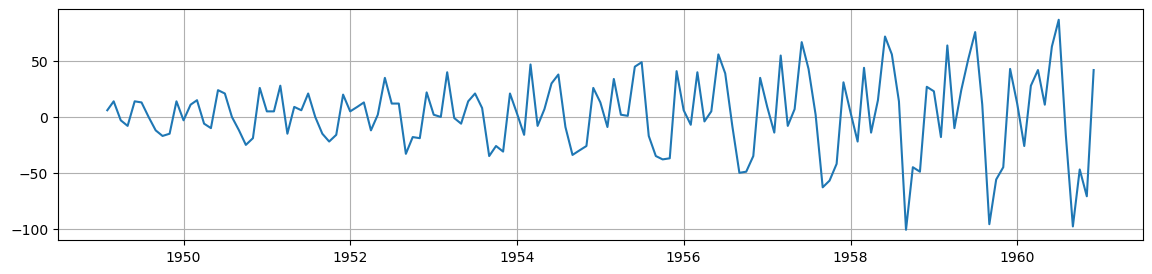

In [39]:
#First order non-seasonal differencing
diff = df['#Passengers'].diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(diff)
plt.show()

In [41]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(diff)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#it is stationary

Results of the Dickey Fuller Test:
Test Statistic             -2.829267
P-value                     0.054213
#Lags used                 12.000000
Number of Observations    130.000000
Critical Value(1%)         -3.481682
Critical Value(5%)         -2.884042
Critical Value(10%)        -2.578770
dtype: float64


In [43]:
kp = kpss(diff)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_2212\3781695736.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff)


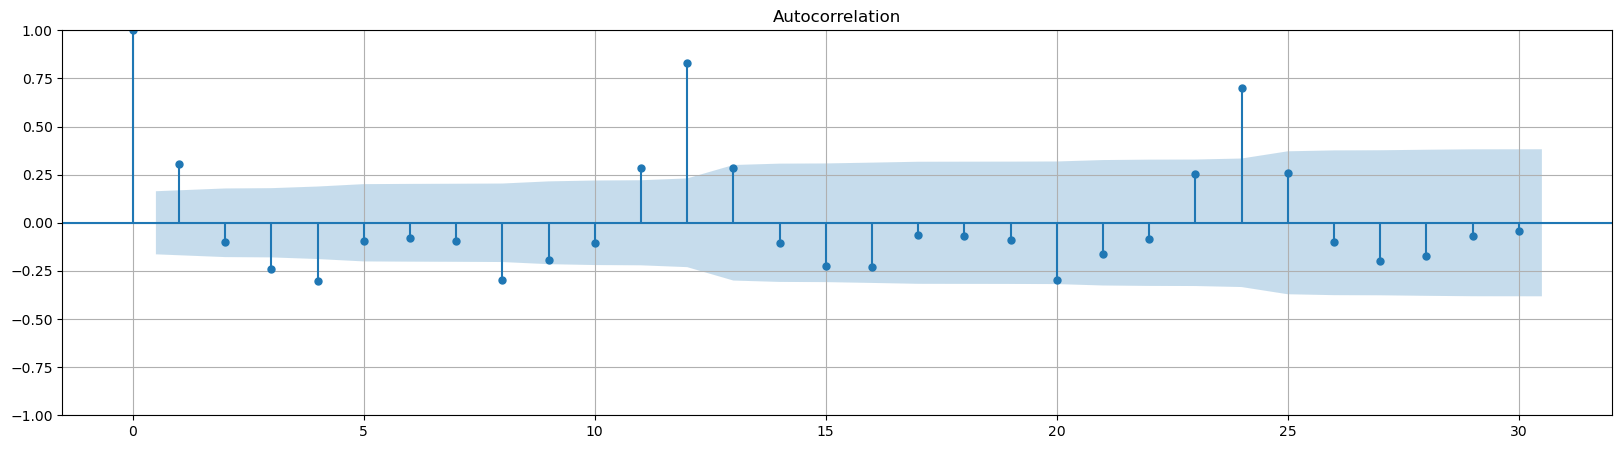

In [45]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(diff, ax=plt.gca(), lags=30)
plt.show()
#not stationary

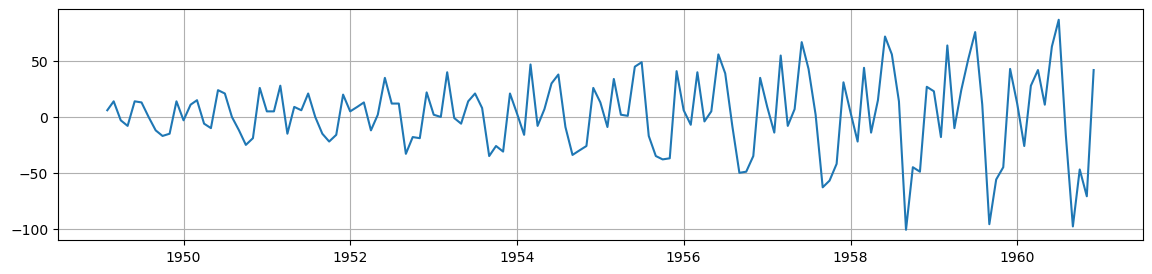

In [46]:
#Second order non-seasonal differencing
diff2 = df['#Passengers'].diff().diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(diff)
plt.show()

In [48]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(diff2)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
# is stationary

Results of the Dickey Fuller Test:
Test Statistic           -1.638423e+01
P-value                   2.732892e-29
#Lags used                1.100000e+01
Number of Observations    1.300000e+02
Critical Value(1%)       -3.481682e+00
Critical Value(5%)       -2.884042e+00
Critical Value(10%)      -2.578770e+00
dtype: float64


In [50]:
kp = kpss(diff2)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_2212\2399534368.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(diff2)


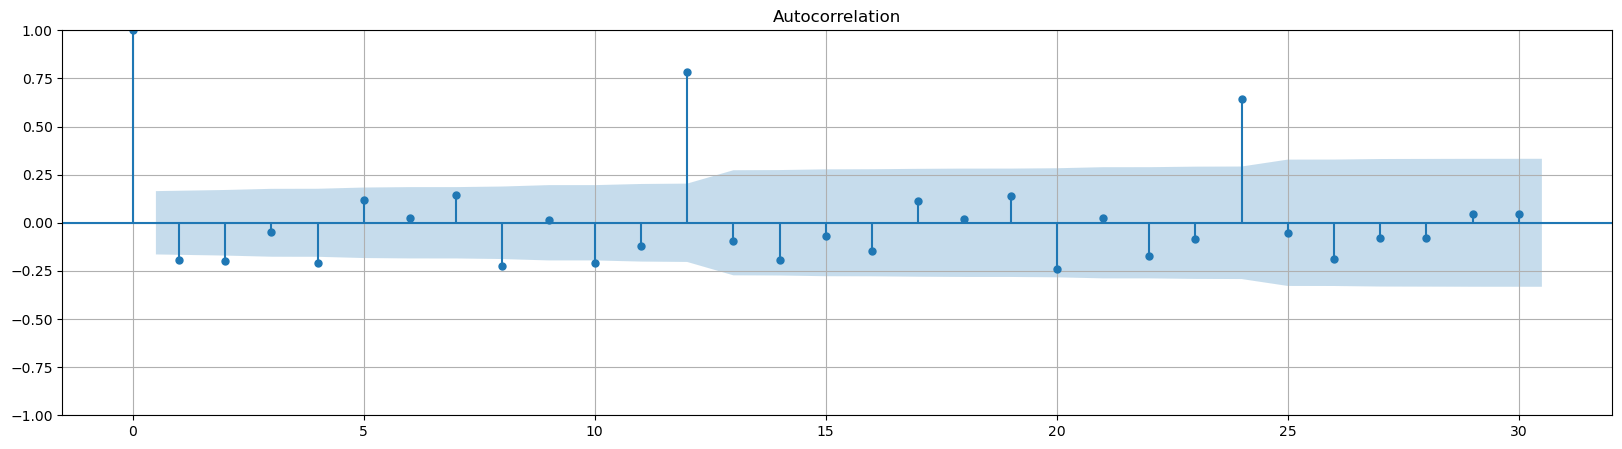

In [52]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(diff2, ax=plt.gca(), lags=30)
plt.show()
#not stationary

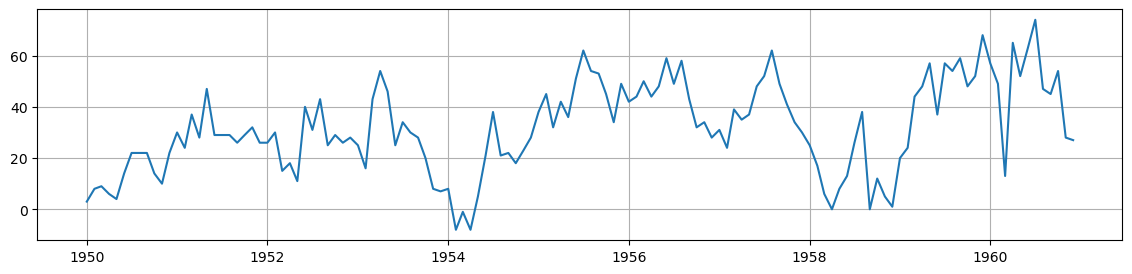

In [53]:
#First order Seasonal differencing
sdiff = df['#Passengers'].diff(periods = 12).dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(sdiff)
plt.show()

In [55]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(sdiff)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#is stationary

Results of the Dickey Fuller Test:
Test Statistic             -3.383021
P-value                     0.011551
#Lags used                  1.000000
Number of Observations    130.000000
Critical Value(1%)         -3.481682
Critical Value(5%)         -2.884042
Critical Value(10%)        -2.578770
dtype: float64


In [57]:
kp = kpss(sdiff)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#not stationary

p-value for KPSS test (untransformed) =  0.03409999422360403


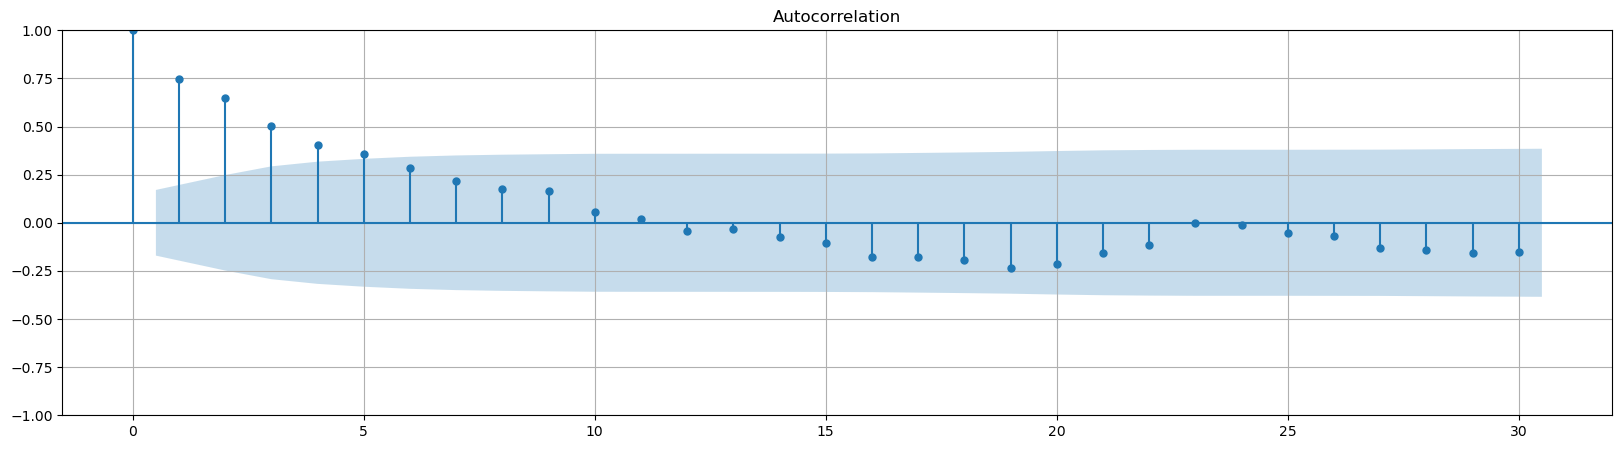

In [60]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(sdiff, ax=plt.gca(), lags=30)
plt.show()
#not stationary

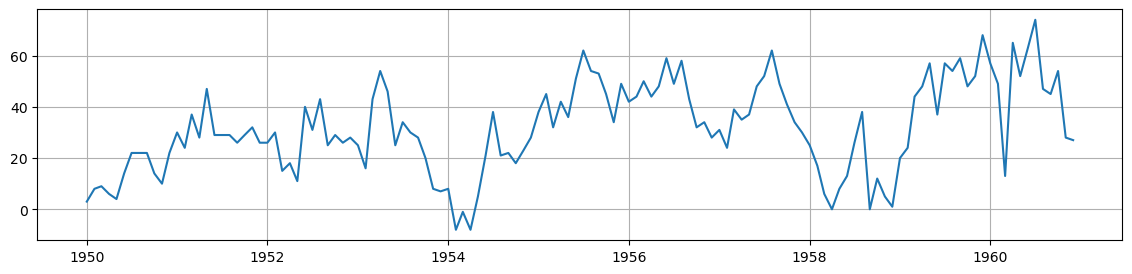

In [61]:
#Seasonal and NON-Seasonal differencing
sdiff = df['#Passengers'].diff(periods = 12).dropna()
sddiff = sdiff.diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(sdiff)
plt.show()

In [63]:
print('Results of the Dickey Fuller Test:')
dftest = adfuller(sddiff)
dfoutput=pd.Series(dftest[0:4],index=["Test Statistic",'P-value','#Lags used','Number of Observations'])
for key,value in dftest[4].items():
    dfoutput['Critical Value(%s)' %key] =value
print(dfoutput)
#is stationary

Results of the Dickey Fuller Test:
Test Statistic           -1.559562e+01
P-value                   1.856512e-28
#Lags used                0.000000e+00
Number of Observations    1.300000e+02
Critical Value(1%)       -3.481682e+00
Critical Value(5%)       -2.884042e+00
Critical Value(10%)      -2.578770e+00
dtype: float64


In [65]:
kp = kpss(sddiff)
p = kp[1]
print ("p-value for KPSS test (untransformed) = ", p)
#is stationary

p-value for KPSS test (untransformed) =  0.1


C:\Users\nmims.student\AppData\Local\Temp\ipykernel_2212\303679635.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(sddiff)


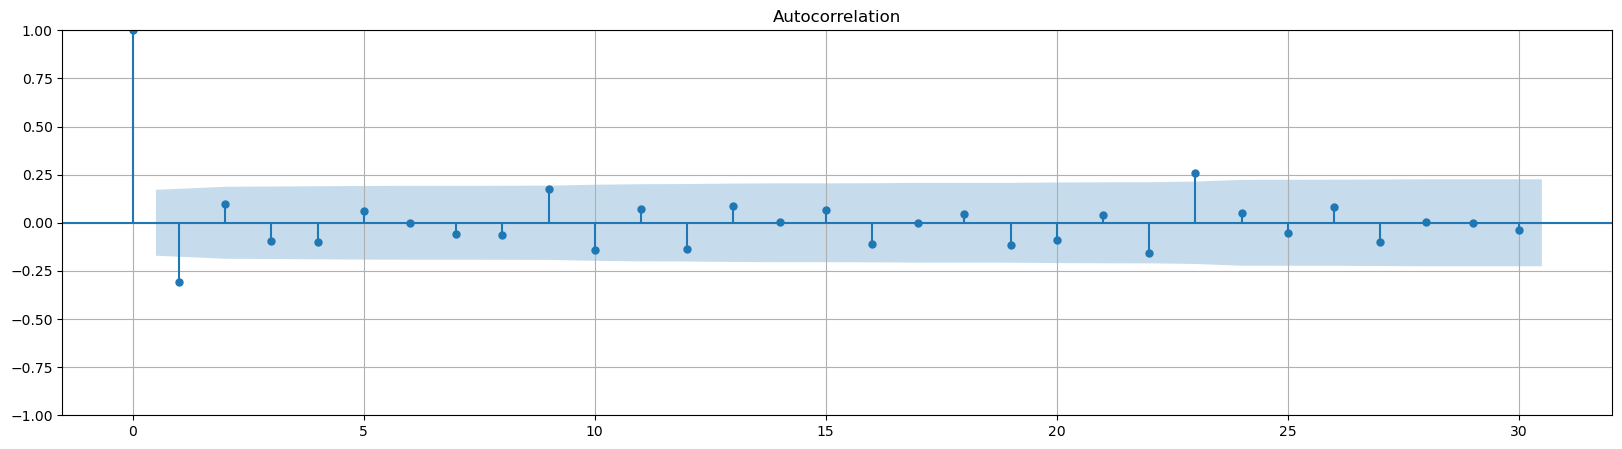

In [67]:
plt.figure(figsize=(20,5))
plt.grid()
plot_acf(sddiff, ax=plt.gca(), lags=30)
plt.show()
#is stationary